# Data gathering script
This program aims to gather data relevant for ML model training and summoner performance score calculation.

In [1]:
import sys
from pathlib import Path

src_dir = str(Path.cwd().parent)
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

from BACKEND.pipeline import load_api_key, pipeline

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
api_key = load_api_key()
test_obj = pipeline(api_key=api_key, platform='EUW1', player_name='401dmg', player_tag='6969', count=1, save=False)
players = test_obj[0]['players']
game_duration = test_obj[0]['metadata']['gameDuration_min']

Caller puuid fetched 0.54
Matches ID fetched 0.97
Matches raw data fetched 1.46
Match object number 1 created. 2.32799
objects created sucessfuly :) 
 Timer: 2.33


### Data cleanup
In this step, unecessary data preserved in server response is deleted. This includes player personal data and irrelevant statistics

In [3]:
for player in players:
    to_drop = ['puuid', 'username', 'championImageLink', 'summonerLevel', 'skillshotsDodged', 'visionWardsBoughtInGame', 'skillshotsHit', 'soloKills', 'doubleKills', 'tripleKills', 'quadraKills', 'pentaKills', 'killingSprees', 'largestKillingSpree', 'itemsPurchased', 'needVisionPings', 'enemyVisionPings', 'allInPings', 'pushPings', 'assistMePings', 'commandPings', 'dangerPings', 'enemyMissingPings', 'onMyWayPings', 'retreatPings', 'physicalDamageDealtToChampions', 'magicDamageDealtToChampions', 'trueDamageDealtToChampions', 'physicalDamageTaken', 'totalHealsOnTeammates', 'totalDamageShieldedOnTeammates', 'summoners', 'runes', 'items', 'icon', 'caller', 'masteries', 'visionScore', 'wardsPlaced',	'wardsKilled', 'detectorWardsPlaced', 'timeCCingOthers']
    for n in to_drop:
        player.pop(n, None)

    to_drop_meta = ['leagueId', 'queueType', 'leaguePoints']
    for i in to_drop_meta:
        player['metadata'].pop(i, None)

    # string = ''
    # for n in player['metadata'].values():
    #     string += str(n) + ' '
    # player['Meta'] = string
    player.pop('metadata')

In [4]:
df = pd.DataFrame(players)

df['win'] = df['win'].map(lambda x: int(x == True))
df['gameEndedInSurrender'] = df['gameEndedInSurrender'].map(lambda x: int(x == True))

df['game_duration'] = game_duration

cols_with_per = ['teamDamagePercentage', 'damageTakenOnTeamPercentage'] #, 'Meta']    
for col in cols_with_per:
    df[col] = df[col].str.replace('%', '')

## Normalization
Feature scaling is utilized to prepare statistics for score calculations. $$x_{norm} = \frac{x - \min(x)}{\max(x) - \min(x)}$$


In [5]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
to_normalize = [
    "kills", #H
    "deaths", #L
    "assists", #H
    "champLevel",
    "KDA", #H
    "killParticipation", #H
    "teamDamagePercentage",#H
    "damageTakenOnTeamPercentage", #L
    "damagePerMinute", #H
    "goldPerMinute", #H
    "visionScorePerMinute", #H
    "maxCsAdvantageOnLaneOpponent", #H
    "goldEarned", #H
    "totalMinionsKilled", #H
    "cs_min", #H
    "totalDamageDealtToChampions", #H
    "totalDamageTaken", #H
    "damageSelfMitigated",  #H
    "damageDealtToObjectives", #H
    "damageDealtToTurrets", #H
    "totalTimeSpentDead" #L
]

for col in to_normalize:    
    df[col] = scaler.fit_transform(df[[col]]).flatten().round(3)

to_invert = ['deaths', 'totalTimeSpentDead']
for col in to_invert:
    df[col] = df[col].map(lambda x: 1 - x).round(3)


### Redundancy check

Text(0.5, 1.0, 'Correlation Matrix for Redundancy Check')

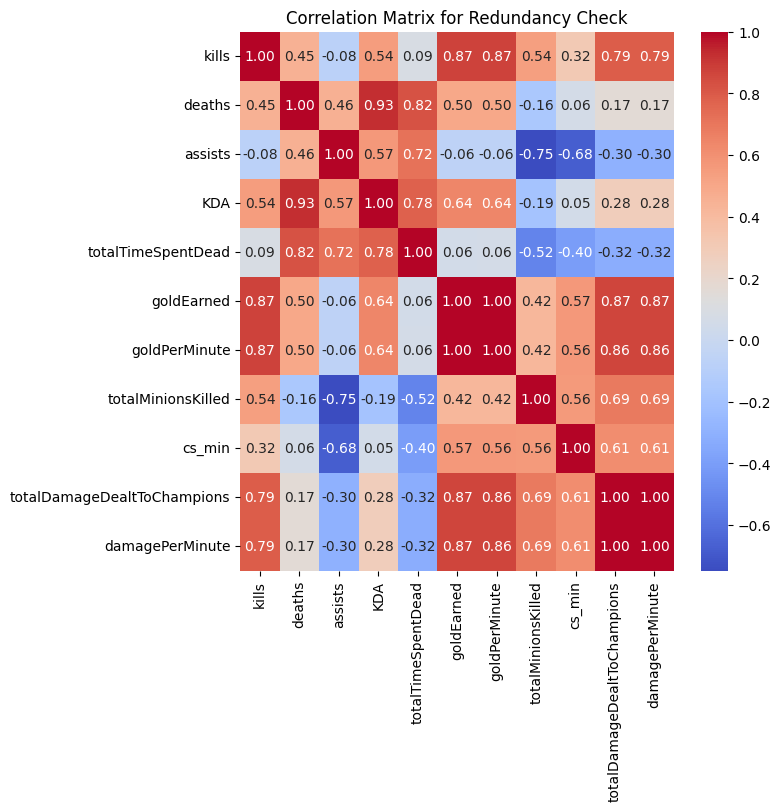

In [6]:
redundancy_check = [
    "kills", "deaths", "assists", "KDA", 
    "totalTimeSpentDead", "goldEarned", "goldPerMinute",
    "totalMinionsKilled", "cs_min", "totalDamageDealtToChampions", "damagePerMinute"
]

corr_matrix = df[redundancy_check].corr()

plt.figure(figsize=(7, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix for Redundancy Check")

In [7]:
df.drop(columns=['goldEarned', 'totalDamageDealtToChampions', 'totalMinionsKilled', 'totalDamageTaken'], inplace=True, errors='ignore')

## Calculating Player Performance Score
Overall equation:
$$PPS = \left(\sum (w_i \cdot x_{i,norm}) \right)$$
Where $w_i$ is a weigthed sum of each statistic. this is changing based on players role.

In [8]:
df.to_csv('test1.csv', sep=',')